In [16]:
import numpy as np
import pandas as pd
import xarray as xr
from itertools import product
import hexMinisom
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import colormaps
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.feature as cf
import pickle
import sammon
import itertools
import colorsys
import random
import datetime as dt
import scipy.stats as stats

In [17]:
def save_som(som, fileName):
    with open(fileName, 'wb') as outfile:
        pickle.dump(som, outfile)

def load_som(fileName):
    with open(fileName, 'rb') as infile:
        som = pickle.load(infile)
    return som

def generate_distinct_colors(n):
    colors = []
    # Generate `n` distinct colors in the HSV color space
    for i in range(n):
        hue = i / n
        saturation = 1.0
        value = 1.0
        rgb = colorsys.hsv_to_rgb(hue, saturation, value)
        rgb = [int(x * 255) for x in rgb]
        hex_color = f"#{rgb[0]:02x}{rgb[1]:02x}{rgb[2]:02x}"
        colors.append(hex_color)
    random.shuffle(colors)
    return colors

# Get the counts of each WR_label for each node in SOM
def get_WR_counts(l, return_percents=False, indices=None):

    # Take only the data from days with the given indices in indices
    if indices is None:
        labels, counts = np.unique([WR_labels[i] for i in l], return_counts=True)
    else:
        labels, counts = np.unique([WR_labels[i] for i in l if i in indices], return_counts=True)

    # If the node has no days of a given regime add the regime to the labels and 0 as its count
    if len(labels) != len(WR_labels_dict.keys()):
        missing_values = np.setdiff1d(list(WR_labels_dict.keys()), labels)
        labels = WR_labels_dict.keys()

        for v in missing_values:
           counts = np.insert(counts, v, 0)

    # Calculate the percents
    if return_percents:
        counts = 100 * counts / sum(counts)
    regime_counts = dict(zip(labels, counts))
    return regime_counts

# Plotting functions
def hex_heatmap(som, data, cmap='Blues', title='', cbLabel=''):
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111)
    ax.set_aspect('equal')
    cmap = mpl.colormaps[cmap]
    
    weights = som.get_weights()
    xx, yy = som.get_euclidean_coordinates()
    
    maxCount = max(v for v in data.values())
    minCount = min(v for v in data.values())
    
    for i in range(weights.shape[0]):
        for j in range(weights.shape[1]):
            if som._mask[i, j] == 0:
                if (i, j) not in data:
                    data[(i,j)] = 0
                    
                wy = yy[(j, i)] * np.sqrt(3) / 2
                colorWeight = data[(i, j)]/maxCount
                
                hex = patches.RegularPolygon(
                    (xx[(j, i)], wy), numVertices=6, radius=.85 / np.sqrt(3), 
                    facecolor=cmap(colorWeight), edgecolor='grey')
                ax.add_patch(hex)
                
                if colorWeight >= .75:
                    textColor = 'white'
                else:
                    textColor = 'black'
                
                plt.text(
                    xx[(j, i)], wy - .07, f'{data[(i, j)]}', 
                    {'horizontalalignment': 'center', 'color': textColor, 'fontsize': 17})
            
    plt.xlim(-1, weights.shape[0] - .5)
    plt.ylim(-1, (weights.shape[1] - .5) * np.sqrt(3) / 2)
    ax.axis('off')
    
    norm = mpl.colors.Normalize(vmin=minCount, vmax=maxCount)
    cb = fig.colorbar(mpl.cm.ScalarMappable(
        norm=norm, cmap=cmap), ax=ax, location='bottom', anchor=(.56, 2.3), shrink=.65, extend='both')
    cb.set_label(cbLabel, fontsize=17)
    cb.ax.tick_params(labelsize=17)
    
    plt.title(title, fontsize=17, y=.95, x=.515)
    return fig

def hex_frequency_plot(som, winmap=None):

    if winmap == None:
        winmap = som.win_map(dataarray)
    
    data = {k: len(v) for k, v in winmap.items()}
    
    fig = hex_heatmap(som, data, 'Blues', '(a) SOM Node Frequencies', 'Count')
    return fig

def hex_plot(som, projection=None):
    """Create a matplot lib figure with an axis for each neuron already positioned into the hexagonal shape"""
    
    n = som._num
    xy = (2 * n) - 1
    mask = som._mask
    node_indices_xy = np.ma.where(mask == False)
    node_indices = list(zip(node_indices_xy[0], node_indices_xy[1]))

    totRows = xy * 3
    totCols = xy * 2
    fig = plt.figure(figsize=[totRows, totCols])
    axs = {}
    
    for x, y in list(product(range(xy), range(xy))):
        if (y, x) in node_indices:
            if y % 2 == 0:
                curRow = x * 3
            else:
                curRow = (x * 3) + 1
                
            curCol = (totCols - 2) - (y * 2)

            ax = plt.subplot2grid(
                (totCols, totRows), (curCol, curRow), rowspan=2, colspan=2, projection=projection)
            ax.set_title(node_nums[(y, x)])
            
            if projection is not None:
                ax.set_extent([-180, -30, 20, 80], crs=projection)
            axs[(y, x)] = ax
    return fig, axs

def find_longest_consecutive_index(arr):
    if not arr.size:
        return -1
    max_len = 0
    start_index = -1
    current_len = 1
    current_start = 0
    for i in range(1, len(arr)):
        if arr[i] == arr[i - 1]:
            current_len += 1
        else:
            if current_len > max_len:
                max_len = current_len
                start_index = current_start
            current_len = 1
            current_start = i
    if current_len > max_len:
        start_index = current_start
    return start_index


# ===========================
# FIXED SIGNIFICANCE FUNCTIONS
# ===========================

def perm_slope_test(y, x, n_perm=10000, seed=0):
    """
    Permutation test for trend (slope) under H0: no association between x and y.
    Shuffles y across x WITHOUT replacement.
    Returns: slope_obs, p_value
    """
    rng = np.random.default_rng(seed)

    x = np.asarray(x)
    y = np.asarray(y)

    # observed slope
    slope_obs = np.polyfit(x, y, 1)[0]

    # permutation null distribution of slopes
    slopes = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        y_perm = rng.permutation(y)
        slopes[i] = np.polyfit(x, y_perm, 1)[0]

    # two-sided permutation p-value with +1 correction
    p = (np.sum(np.abs(slopes) >= np.abs(slope_obs)) + 1) / (n_perm + 1)

    return slope_obs, p


def bh_fdr(pvals, q=0.05):
    """
    Benjamini–Hochberg FDR control.
    Returns a boolean array: True if significant under FDR at level q.
    """
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)

    order = np.argsort(pvals)
    ranked = pvals[order]

    thresh = q * (np.arange(1, m + 1) / m)
    passed = ranked <= thresh

    sig = np.zeros(m, dtype=bool)
    if np.any(passed):
        k = np.max(np.where(passed))
        cutoff = ranked[k]
        sig = pvals <= cutoff

    return sig

def seasonal_trend_stats(season_winmap, season_name, node_list, bin_size=10,
                         start_year=1944, n_perm=10000, base_seed=12345):

    slopes = []
    pvals = []

    for idx, node in enumerate(node_list):
        indices = season_winmap.get(node, [])

        if len(indices) == 0:
            slopes.append(np.nan)
            pvals.append(np.nan)
            continue

        dates_labels = WR_labels_df.iloc[indices][['date', 'WR']]
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= start_year])

        if len(dates_labels_truncated) == 0:
            slopes.append(np.nan)
            pvals.append(np.nan)
            continue

        dates_labels_truncated['year_group'] = (
            (dates_labels_truncated['date'].dt.year - 4) // bin_size
        ) * bin_size + 4

        groups = dates_labels_truncated.groupby('year_group').size()

        if len(groups) < 3:
            slopes.append(np.nan)
            pvals.append(np.nan)
            continue

        slope_obs, pval = perm_slope_test(
            y=groups.values,
            x=groups.index.values,
            n_perm=n_perm,
            seed=base_seed + idx
        )

        slopes.append(slope_obs)
        pvals.append(pval)

    pvals_arr = np.array(pvals, dtype=float)
    valid_mask = np.isfinite(pvals_arr)

    sig_fdr05 = np.zeros(len(pvals_arr), dtype=bool)
    if np.any(valid_mask):
        sig_fdr05[valid_mask] = bh_fdr(pvals_arr[valid_mask], q=0.05)

    results = pd.DataFrame({
        "season": season_name,
        "node": node_list,
        "node_num": [node_nums[n] for n in node_list],
        "slope_days_per_year": slopes,
        "slope_days_per_decade": np.array(slopes) * 10,
        "p_value": pvals,
        "sig_90": pvals_arr < 0.10,
        "sig_95": pvals_arr < 0.05,
        "sig_fdr_05": sig_fdr05
    })

    return results.sort_values("p_value")

def compute_season_perm_pvals(season_winmap, node_list, bin_size=10,
                              start_year=1944, n_perm=10000, base_seed=12345):
    slopes = []
    pvals = []

    for idx, node in enumerate(node_list):
        indices = season_winmap.get(node, [])

        if len(indices) == 0:
            slopes.append(np.nan)
            pvals.append(np.nan)
            continue

        dates_labels = WR_labels_df.iloc[indices][['date', 'WR']]
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= start_year])

        if len(dates_labels_truncated) == 0:
            slopes.append(np.nan)
            pvals.append(np.nan)
            continue

        dates_labels_truncated['year_group'] = (
            (dates_labels_truncated['date'].dt.year - 4) // bin_size
        ) * bin_size + 4

        groups = dates_labels_truncated.groupby('year_group').size()

        if len(groups) < 3:
            slopes.append(np.nan)
            pvals.append(np.nan)
            continue

        slope_obs, pval = perm_slope_test(
            y=groups.values,
            x=groups.index.values,
            n_perm=n_perm,
            seed=base_seed + idx
        )

        slopes.append(slope_obs)
        pvals.append(pval)

    return np.array(slopes, dtype=float), np.array(pvals, dtype=float)

def seasonal_fdr(pvals, q=0.05):
    valid = np.isfinite(pvals)
    sig = np.zeros_like(valid, dtype=bool)
    if np.any(valid):
        sig[valid] = bh_fdr(pvals[valid], q=q)
    return sig

In [49]:
path_anoms = '/glade/derecho/scratch/jhayron/Data4WRsClimateChange/ProcessedDataReanalyses/'
reanalysis = 'ERA5'
path_data = f'{path_anoms}Z500Anoms_{reanalysis}.nc'
dataset = xr.open_dataarray(path_data)

# needed_lat = dataset.lat
# needed_lon = dataset.lon

# ### Load new reanalysis mirroring coordinates

# reanalysis = 'JRA3Q'
# path_data = f'{path_anoms}Z500Anoms_{reanalysis}.nc'
# dataset = xr.open_dataarray(path_data)
# dataset = dataset.sel(lat=needed_lat,lon=needed_lon,method='nearest').compute()
# dataset.to_netcdf(f'{path_anoms}Z500Anoms_{reanalysis}_4trendsLuke.nc')

In [50]:
# path_anoms = '/glade/derecho/scratch/jhayron/Data4WRsClimateChange/ProcessedDataReanalyses/'
# reanalysis = 'NCEP_NCAR'
# path_data = f'{path_anoms}Z500Anoms_{reanalysis}_4trendsLuke.nc'
# dataset = xr.open_dataarray(path_data)

In [51]:
latSlice = slice(20, 80) #20N, 80N
lonSlice = slice(180, 330) #180W, 30W
dataarray = dataset.sel(lat=latSlice, lon=lonSlice)
dataarray = dataarray.stack(latlon=['lat', 'lon']).values

# Seasonal breakdown of the data
DJF = dataset.time.dt.month.isin([12, 1, 2])
DJF_idxs = np.array(DJF).nonzero()[0]
MAM = dataset.time.dt.month.isin([3, 4, 5])
MAM_idxs = np.array(MAM).nonzero()[0]
JJA = dataset.time.dt.month.isin([6, 7, 8])
JJA_idxs = np.array(JJA).nonzero()[0]
SON = dataset.time.dt.month.isin([9, 10, 11])
SON_idxs = np.array(SON).nonzero()[0]

print(dataarray.shape)

(30660, 9211)


In [52]:
som = load_som('../SOM40.p')

n = som._num
xy = hexMinisom.xy_using_n(n)

mask = som._mask
node_indices_xy = np.ma.where(mask == False)
node_indices = list(zip(node_indices_xy[0], node_indices_xy[1]))
all_nodes = product(range(xy), range(xy))

inputLength = dataarray.shape[1]

winmap = som.win_map(dataarray, return_indices=True)
# Seasonal breakdown for winmap
DJF_winmap = {}
MAM_winmap = {}
JJA_winmap = {}
SON_winmap = {}

for k, v in winmap.items():
    DJF_winmap[k] = [i for i in v if i in DJF_idxs]
    MAM_winmap[k] = [i for i in v if i in MAM_idxs]
    JJA_winmap[k] = [i for i in v if i in JJA_idxs]
    SON_winmap[k] = [i for i in v if i in SON_idxs]

w = som._weights
minimum_weight = -np.max(np.abs(w))
maximum_weight = np.max(np.abs(w))

# Calculate the node number for each coordinate
node_nums = {}
n = 1
for i in range(mask.shape[0])[::-1]:
    for j in range(mask.shape[1]):
        if som._mask[i, j] == 0:
            node_nums[(i, j)] = n
            n += 1

color_list = generate_distinct_colors(len(node_indices))

In [53]:
print(som._sigma_decay_function)
print(som._learning_rate_decay_function)
print(som._learning_rate)
print(som.neighborhood)
print(som._activation_distance)

<bound method MiniSom._asymptotic_decay of <hexMinisom.MiniSom object at 0x15215e746e70>>
<bound method MiniSom._asymptotic_decay of <hexMinisom.MiniSom object at 0x15215e746e70>>
0.001
<bound method MiniSom._gaussian of <hexMinisom.MiniSom object at 0x15215e746e70>>
<bound method MiniSom._euclidean_distance of <hexMinisom.MiniSom object at 0x15215e746e70>>


In [54]:
# Import the regime labels
WR_labels_df = pd.read_csv(f'../data/df_labels_nocorrfilt_{reanalysis}.csv')
WR_labels_df.rename(columns={'Unnamed: 0': 'date'}, inplace=True)
WR_labels_df['date'] = pd.to_datetime(WR_labels_df['date'], format='%Y-%m-%d')
WR_labels_dict = {
    0: 'Greenland High', 1: 'Pacific Trough', 2: 'Pacific Ridge', 
    3: 'Alaskan Ridge', 4: 'North American\nAtlantic Ridge', 5: 'No WR'
}
WR_labels = np.array(WR_labels_df['WR'])

WRs_by_node = {k: get_WR_counts(v) for k, v in winmap.items()}
WRs_percents = {k: get_WR_counts(v, return_percents=True) for k, v in winmap.items()}

print(WR_labels_df)

# Calculate the 90th percentile of the distances and only keep data less than that
percentile90 = np.percentile(WR_labels_df['distances'], 90)
lt90 = (np.array(WR_labels_df['distances']) < percentile90).nonzero()[0]
WRs_lt90 = {k: get_WR_counts(v, True, lt90) for k, v in winmap.items()}

# Calculate the variances of the distances for each WR
WR_indices = {i: (WR_labels == i).nonzero()[0] for i in np.unique(WR_labels)}
for WR, idxs in WR_indices.items():
    variance = np.var(WR_labels_df['distances'].iloc[idxs])
    
# Get the WR counts for each specific season
WRs_DJF = {k: get_WR_counts(v, True, DJF_idxs) for k, v in winmap.items()}
WRs_MAM = {k: get_WR_counts(v, True, MAM_idxs) for k, v in winmap.items()}
WRs_JJA = {k: get_WR_counts(v, True, JJA_idxs) for k, v in winmap.items()}
WRs_SON = {k: get_WR_counts(v, True, SON_idxs) for k, v in winmap.items()}

            date  WR  distances      corr
0     1940-01-01   0   2.463938  0.518457
1     1940-01-02   0   2.662645  0.565398
2     1940-01-03   0   2.916932  0.552532
3     1940-01-04   0   3.122750  0.495652
4     1940-01-05   0   3.302769  0.394692
...          ...  ..        ...       ...
30655 2023-12-27   1   2.823370  0.857459
30656 2023-12-28   1   2.687266  0.837698
30657 2023-12-29   1   2.394127  0.781903
30658 2023-12-30   1   2.253624  0.655454
30659 2023-12-31   0   2.468174  0.359541

[30660 rows x 4 columns]


In [55]:
bin_size = 10  # in years

# Use a stable node iteration order so lists align with plotting
node_list = list(winmap.keys())

slopes = []
pvals = []

base_seed = 12345
n_perm = 10000

for idx, node in enumerate(node_list):
    indices = winmap[node]

    dates_labels = WR_labels_df.iloc[indices][['date', 'WR']]

    # Remove the first 4 years of our data for even bins
    if reanalysis == 'ERA5':
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1944])
    else:
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1954])

    # Make the groups
    dates_labels_truncated['year_group'] = (
        (dates_labels_truncated['date'].dt.year - 4) // bin_size
    ) * bin_size + 4

    # Count days per bin
    groups = dates_labels_truncated.groupby('year_group').size()

    # Guard: too few bins -> still plot bars later, but skip significance
    if len(groups) < 3:
        slopes.append(np.nan)
        pvals.append(np.nan)
        continue

    # Compute slope and permutation p-value
    slope_obs, pval = perm_slope_test(
        y=groups.values,
        x=groups.index.values,
        n_perm=n_perm,
        seed=base_seed + idx
    )

    slopes.append(slope_obs)
    pvals.append(pval)

# Optional: FDR significance (computed but NOT used in plotting so style is unchanged)
valid_mask = ~np.isnan(pvals)
sig_fdr05 = np.zeros(len(pvals), dtype=bool)
if np.any(valid_mask):
    sig_fdr05[valid_mask] = bh_fdr(np.array(pvals)[valid_mask], q=0.05)

results = pd.DataFrame({
    "node": node_list,
    "node_num": [node_nums[n] for n in node_list],
    "slope_days_per_year": slopes,
    "slope_days_per_decade": np.array(slopes) * 10,
    "p_value": pvals,
    "sig_90": np.array(pvals) < 0.10,
    "sig_95": np.array(pvals) < 0.05,
    "sig_fdr_05": sig_fdr05
})

# Sort by most significant p-values
results_sorted = results.sort_values("p_value")
print(results_sorted.head(15))

      node  node_num  slope_days_per_year  slope_days_per_decade   p_value  \
29  (1, 1)        29             0.555952               5.559524  0.045395   
14  (3, 2)        18             0.432143               4.321429  0.045795   
13  (4, 3)        12             0.478571               4.785714  0.060694   
11  (5, 4)         8            -0.304762              -3.047619  0.097990   
28  (2, 1)        23             0.385714               3.857143  0.129387   
36  (3, 5)        21             0.200000               2.000000  0.183182   
2   (3, 0)        16             0.350000               3.500000  0.249675   
4   (0, 3)        35            -0.267857              -2.678571  0.251775   
10  (5, 3)         7            -0.114286              -1.142857  0.256474   
19  (5, 2)         6             0.134524               1.345238  0.262074   
5   (0, 2)        34            -0.921429              -9.214286  0.262674   
7   (6, 3)         2            -0.464286              -4.642857

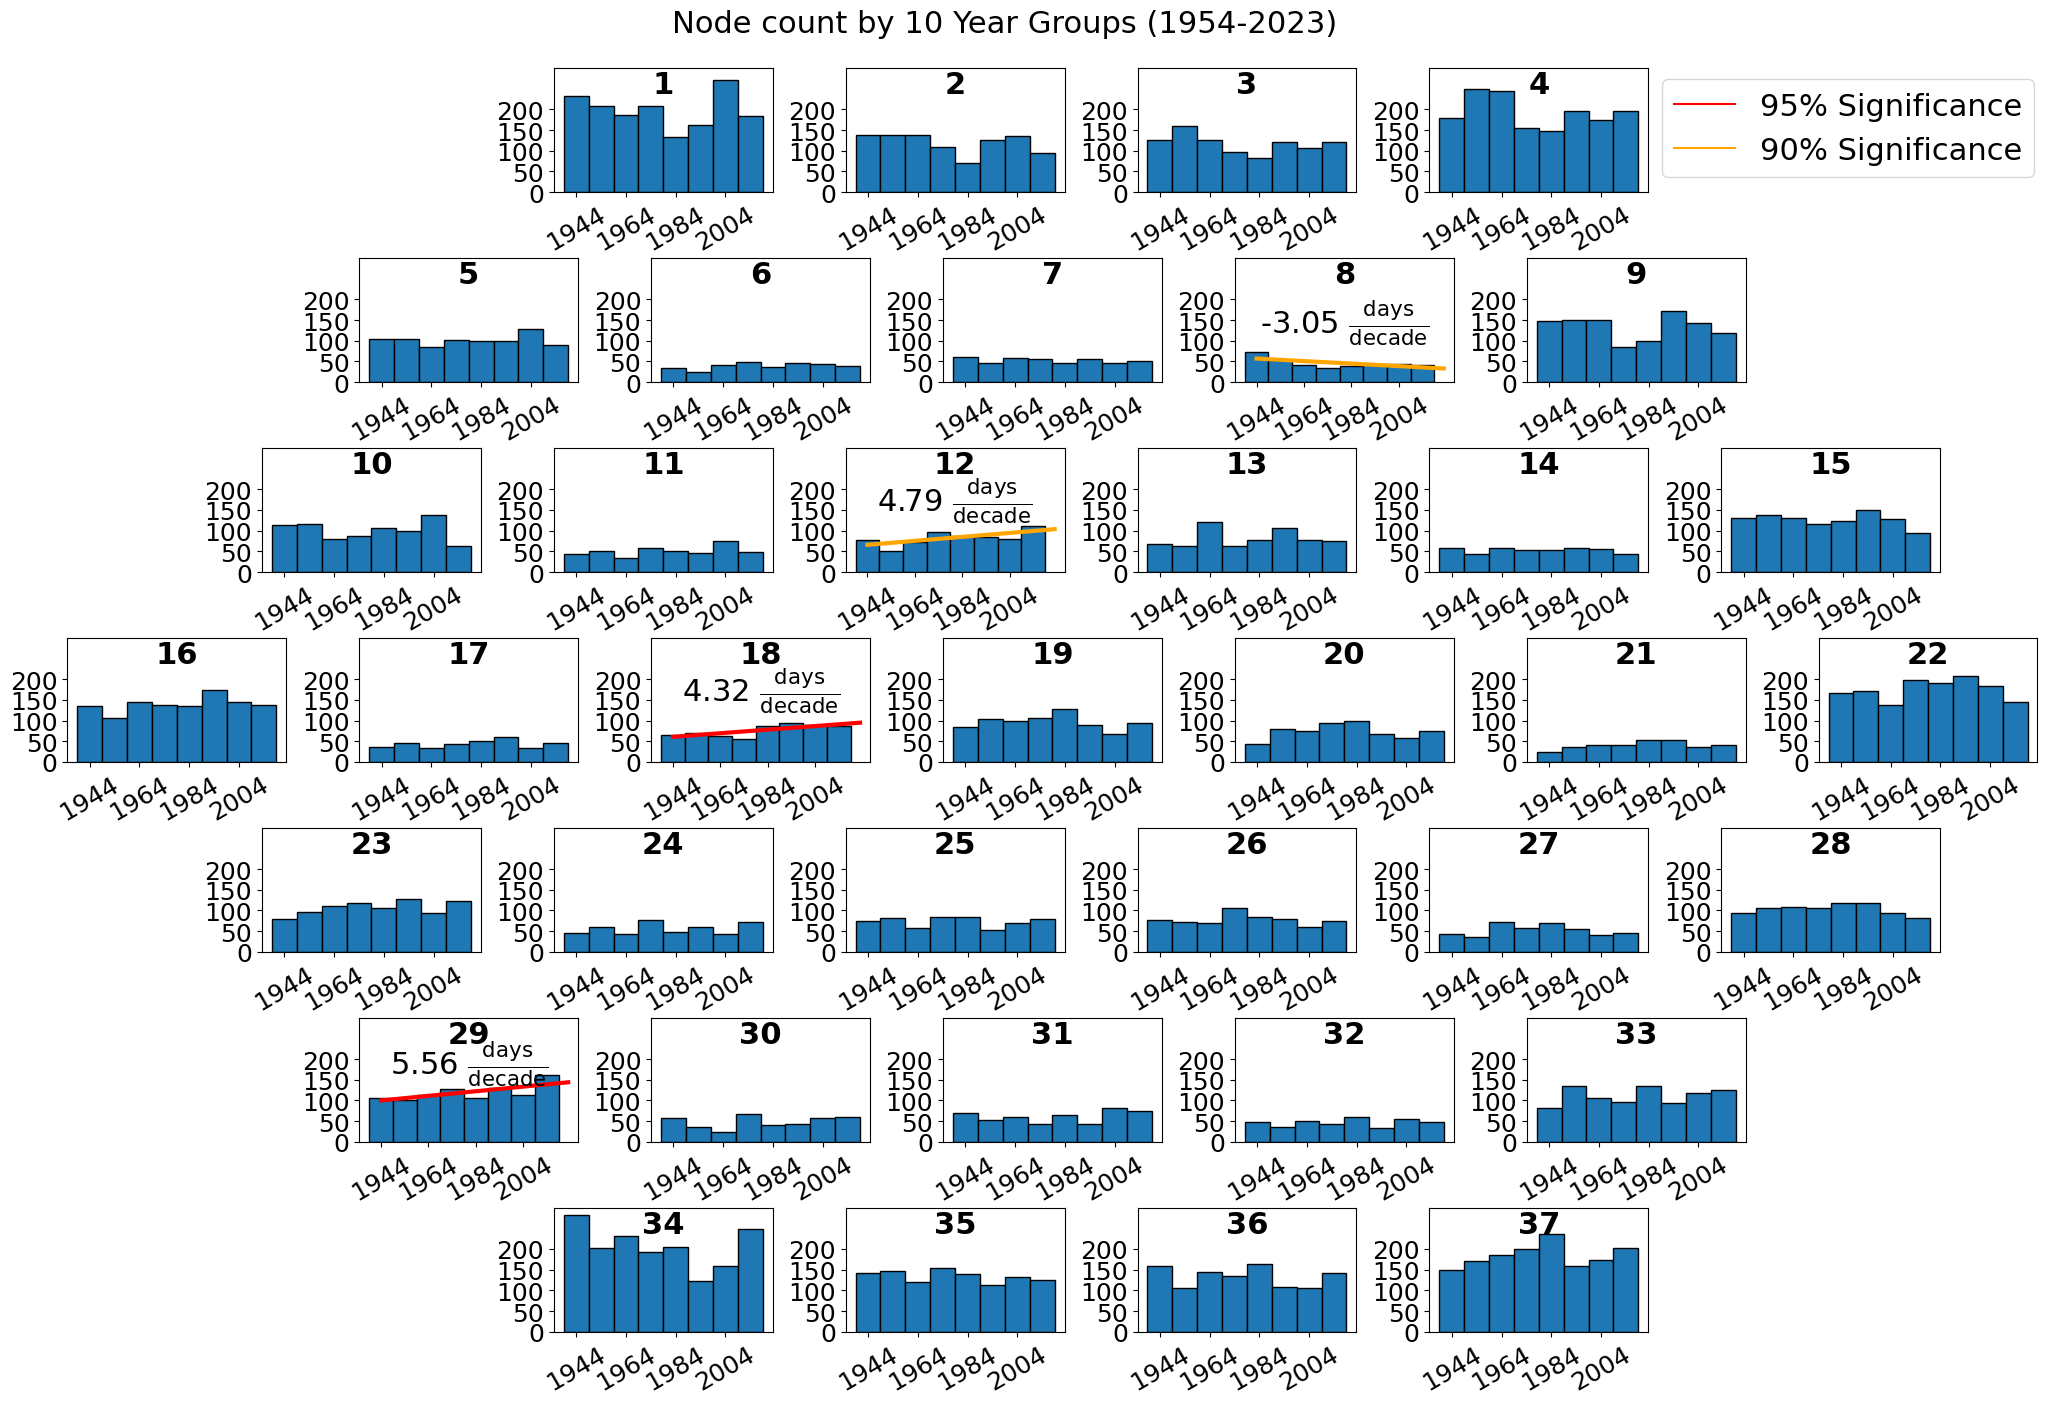

In [56]:
plt.rcParams['text.usetex'] = False
fig, axs = hex_plot(som)
timeData = {}
maxBin = 300

fs = 22

for idx, node in enumerate(node_list):
    indices = winmap[node]
    ax = axs[node[0], node[1]]

    # Get the labels for each of the days grouped into the current node
    dates_labels = WR_labels_df.iloc[indices][['date', 'WR']]

    # Remove the first 4 years of our data for even bins
    if reanalysis == 'ERA5':
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1944])
    else:
        dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1954])

    # Make the groups
    dates_labels_truncated['year_group'] = (
        (dates_labels_truncated['date'].dt.year - 4) // bin_size
    ) * bin_size + 4

    # Count days per bin
    groups = dates_labels_truncated.groupby('year_group').size()

    # Keep track of the largest bin
    if len(groups) > 0 and max(groups) > maxBin:
        maxBin = max(groups)

    # Plot the bins as a bar plot (UNCHANGED)
    ax.bar(groups.index, groups, width=bin_size, edgecolor='k')

    # Compute polyfit trend for plotting line (same as you did)
    # (Only draw line if significant at 90%)
    slope_obs = slopes[idx]
    pval = pvals[idx]

    # Only attempt to draw trend line if we have enough bins and a valid p-value
    if len(groups) >= 3 and np.isfinite(pval):

        z = np.polyfit(list(groups.index), groups, 1)
        trend = z[0]

        # Plot trend only if it is significant at 90% (UNCHANGED BEHAVIOR)
        if pval < 0.10:
            p = np.poly1d(z)
            x = np.arange(groups.index[0], groups.index[-1] + bin_size)
            y = p(x)

            # Text placement logic (UNCHANGED)
            if node == (1, 1):
                ax.text(
                    .5, .55, f'{trend*10:.2f} ' + r'$\frac{\text{days}}{\text{decade}}$',
                    transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
                )
            elif node == (5, 4):
                ax.text(
                    .5, .4, f'{trend*10:.2f} ' + r'$\frac{\text{days}}{\text{decade}}$',
                    transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
                )
            else:
                ax.text(
                    .5, .5, f'{trend*10:.2f} ' + r'$\frac{\text{days}}{\text{decade}}$',
                    transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
                )

            # Color logic (UNCHANGED STYLE): red for 95%, orange for 90%
            if pval < 0.05:
                color = 'r'
            else:
                color = 'orange'

            ax.plot(x, y, c=color, linewidth=3)

    # Axis formatting (UNCHANGED)
    ax.set_xticks(groups.index[::2])
    ax.set_yticks([0, 50, 100, 150, 200])
    ax.tick_params(axis='x', labelrotation=30, labelsize=fs - 4)
    ax.tick_params(axis='y', labelsize=fs - 4)
    ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})

# Loop through each axis to change y axis scale (UNCHANGED)
for node in node_indices:
    axs[node[0], node[1]].set_ylim(0, maxBin)

plt.suptitle(f"Node count by {bin_size} Year Groups (1954-2023)", y=1.0, fontsize=22)
fig.tight_layout()

# Create dummy data so a legend can be made for the significance (UNCHANGED)
plt.plot([1944], [0], color='r', label='95% Significance')
plt.plot([1944], [0], color='orange', label='90% Significance')
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 4.09), fontsize=fs)

plt.subplots_adjust(wspace=-0.2, hspace=2.25)

plt.savefig(f'node_count_trends_{bin_size}_{reanalysis}.png', transparent=True, bbox_inches='tight')
plt.show()

## seasons

In [9]:
# --- compute all seasons ---
DJF_slopes, DJF_pvals = compute_season_perm_pvals(DJF_winmap, node_list, bin_size, 1944, n_perm, base_seed)
MAM_slopes, MAM_pvals = compute_season_perm_pvals(MAM_winmap, node_list, bin_size, 1944, n_perm, base_seed)
JJA_slopes, JJA_pvals = compute_season_perm_pvals(JJA_winmap, node_list, bin_size, 1944, n_perm, base_seed)
SON_slopes, SON_pvals = compute_season_perm_pvals(SON_winmap, node_list, bin_size, 1944, n_perm, base_seed)

In [10]:
DJF_sig_fdr05 = seasonal_fdr(DJF_pvals, q=0.05)
MAM_sig_fdr05 = seasonal_fdr(MAM_pvals, q=0.05)
JJA_sig_fdr05 = seasonal_fdr(JJA_pvals, q=0.05)
SON_sig_fdr05 = seasonal_fdr(SON_pvals, q=0.05)

In [11]:
node_list = list(winmap.keys())

DJF_results_sorted = seasonal_trend_stats(DJF_winmap, "DJF", node_list, bin_size=10)
MAM_results_sorted = seasonal_trend_stats(MAM_winmap, "MAM", node_list, bin_size=10)
JJA_results_sorted = seasonal_trend_stats(JJA_winmap, "JJA", node_list, bin_size=10)
SON_results_sorted = seasonal_trend_stats(SON_winmap, "SON", node_list, bin_size=10)

print(DJF_results_sorted.head(10))
print(MAM_results_sorted.head(10))
print(JJA_results_sorted.head(10))
print(SON_results_sorted.head(10))

   season    node  node_num  slope_days_per_year  slope_days_per_decade  \
7     DJF  (6, 3)         2            -0.292857              -2.928571   
34    DJF  (4, 6)        15            -0.102381              -1.023810   
14    DJF  (3, 2)        18             0.197619               1.976190   
12    DJF  (6, 4)         3            -0.294048              -2.940476   
28    DJF  (2, 1)        23             0.269048               2.690476   
10    DJF  (5, 3)         7            -0.132143              -1.321429   
29    DJF  (1, 1)        29             0.177381               1.773810   
21    DJF  (3, 4)        20             0.121429               1.214286   
3     DJF  (2, 2)        24             0.166667               1.666667   
31    DJF  (2, 6)        28             0.148810               1.488095   

     p_value  sig_90  sig_95  sig_fdr_05  
7   0.047395    True    True       False  
34  0.069793    True   False       False  
14  0.095990    True   False       False  
12

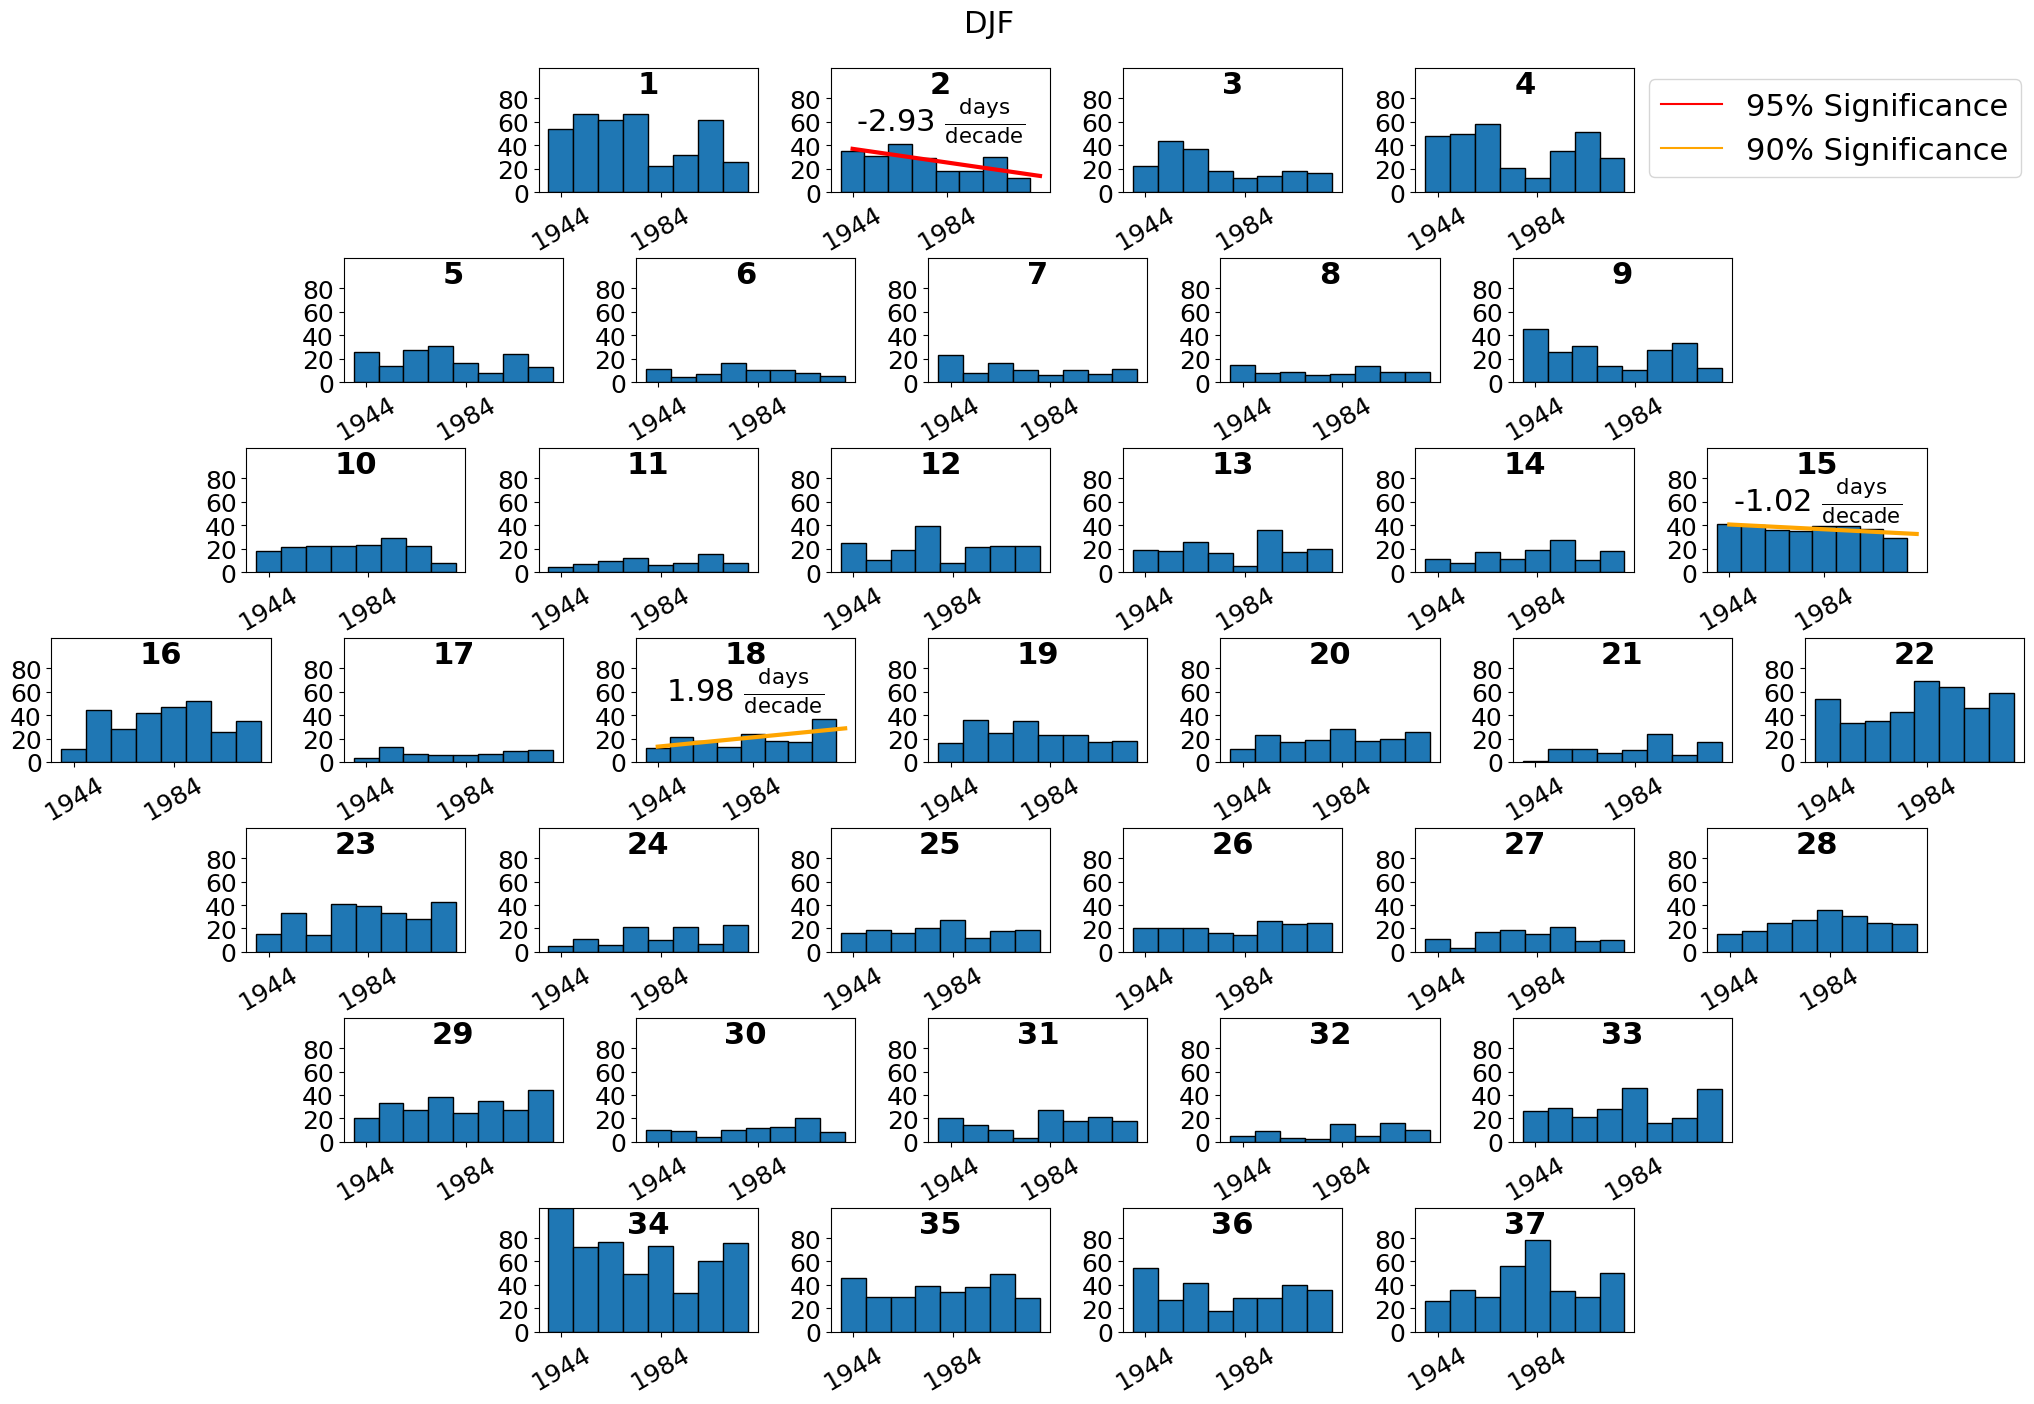

In [12]:
plt.rcParams['text.usetex'] = False
fig, axs = hex_plot(som)
timeData = {}
maxBin = 80

fs = 22

# IMPORTANT: iterate in node_list order so DJF_pvals[idx] matches the correct node
for idx, node in enumerate(node_list):

    ax = axs[node[0], node[1]]

    # Get seasonal indices for this node (may be empty)
    indices = DJF_winmap.get(node, [])

    # If no DJF samples for this node, just leave it blank (same overall style)
    if len(indices) == 0:
        ax.set_xticks([])
        ax.set_yticks([0, 20, 40, 60, 80])
        ax.tick_params(axis='y', labelsize=fs - 4)
        ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})
        continue

    # Get the labels for each of the days grouped into the current node
    dates_labels = WR_labels_df.iloc[indices][['date', 'WR']]

    # Remove the first 4 years of our data for even bins
    dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1944])

    # If empty after truncation, skip plotting for this node
    if len(dates_labels_truncated) == 0:
        ax.set_xticks([])
        ax.set_yticks([0, 20, 40, 60, 80])
        ax.tick_params(axis='y', labelsize=fs - 4)
        ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})
        continue

    # Make the groups
    dates_labels_truncated['year_group'] = (
        (dates_labels_truncated['date'].dt.year - 4) // bin_size
    ) * bin_size + 4

    # group by the groups just made
    groups = dates_labels_truncated.groupby('year_group').size()

    # If there are no bins, skip
    if len(groups) == 0:
        ax.set_xticks([])
        ax.set_yticks([0, 20, 40, 60, 80])
        ax.tick_params(axis='y', labelsize=fs - 4)
        ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})
        continue

    # Keep track of the largest bin
    if max(groups) > maxBin:
        maxBin = max(groups)

    # Plot the bins as a bar plot (UNCHANGED)
    ax.bar(groups.index, groups, width=bin_size, edgecolor='k')

    # Permutation p-value for this node (NEW)
    pval = DJF_pvals[idx]

    # Calculate the trend of the actual data (UNCHANGED)
    # (only compute if at least 2 points; you typically have 8 bins, but keep safe)
    if len(groups) >= 2:
        z = np.polyfit(groups.index, groups, 1)
    else:
        z = None

    # Plot trend only if it is significant at 90% (NEW CRITERION)
    # Matches your old behavior of only drawing when "significant"
    if (z is not None) and np.isfinite(pval) and (pval < 0.10):

        p = np.poly1d(z)
        x = np.arange(groups.index[0], groups.index[-1] + bin_size)
        y = p(x)

        # Text placement logic (UNCHANGED)
        if node == (1, 1):
            ax.text(
                .5, .55, f'{z[0]*10:.2f} ' + r'$\frac{\text{days}}{\text{decade}}$',
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        elif node == (5, 4):
            ax.text(
                .5, .4, f'{z[0]*10:.2f} ' + r'$\frac{\text{days}}{\text{decade}}$',
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        else:
            ax.text(
                .5, .5, f'{z[0]*10:.2f} ' + r'$\frac{\text{days}}{\text{decade}}$',
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )

        # Plot with different colors depending on significance (UNCHANGED STYLE)
        # Red if p < 0.05, orange if 0.05 <= p < 0.10
        if pval < 0.05:
            color = 'r'
        else:
            color = 'orange'

        ax.plot(x, y, c=color, linewidth=3)

    # Axis formatting (UNCHANGED)
    ax.set_xticks(groups.index[::4])
    ax.set_yticks([0, 20, 40, 60, 80])
    ax.tick_params(axis='x', labelrotation=30, labelsize=fs - 4)
    ax.tick_params(axis='y', labelsize=fs - 4)
    ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})

# Loop through each axis to change y axis scale (UNCHANGED)
for node in node_indices:
    axs[node[0], node[1]].set_ylim(0, maxBin)

plt.suptitle("DJF", y=1.0, fontsize=22)
fig.tight_layout()

# Create dummy data so a legend can be made for the significance (UNCHANGED)
plt.plot([1944], [0], color='r', label='95% Significance')
plt.plot([1944], [0], color='orange', label='90% Significance')
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 4.09), fontsize=fs)

plt.subplots_adjust(wspace=-0.2, hspace=2.25)

plt.savefig('node_count_trends_DJF.pdf', transparent=True, bbox_inches='tight')
plt.show()

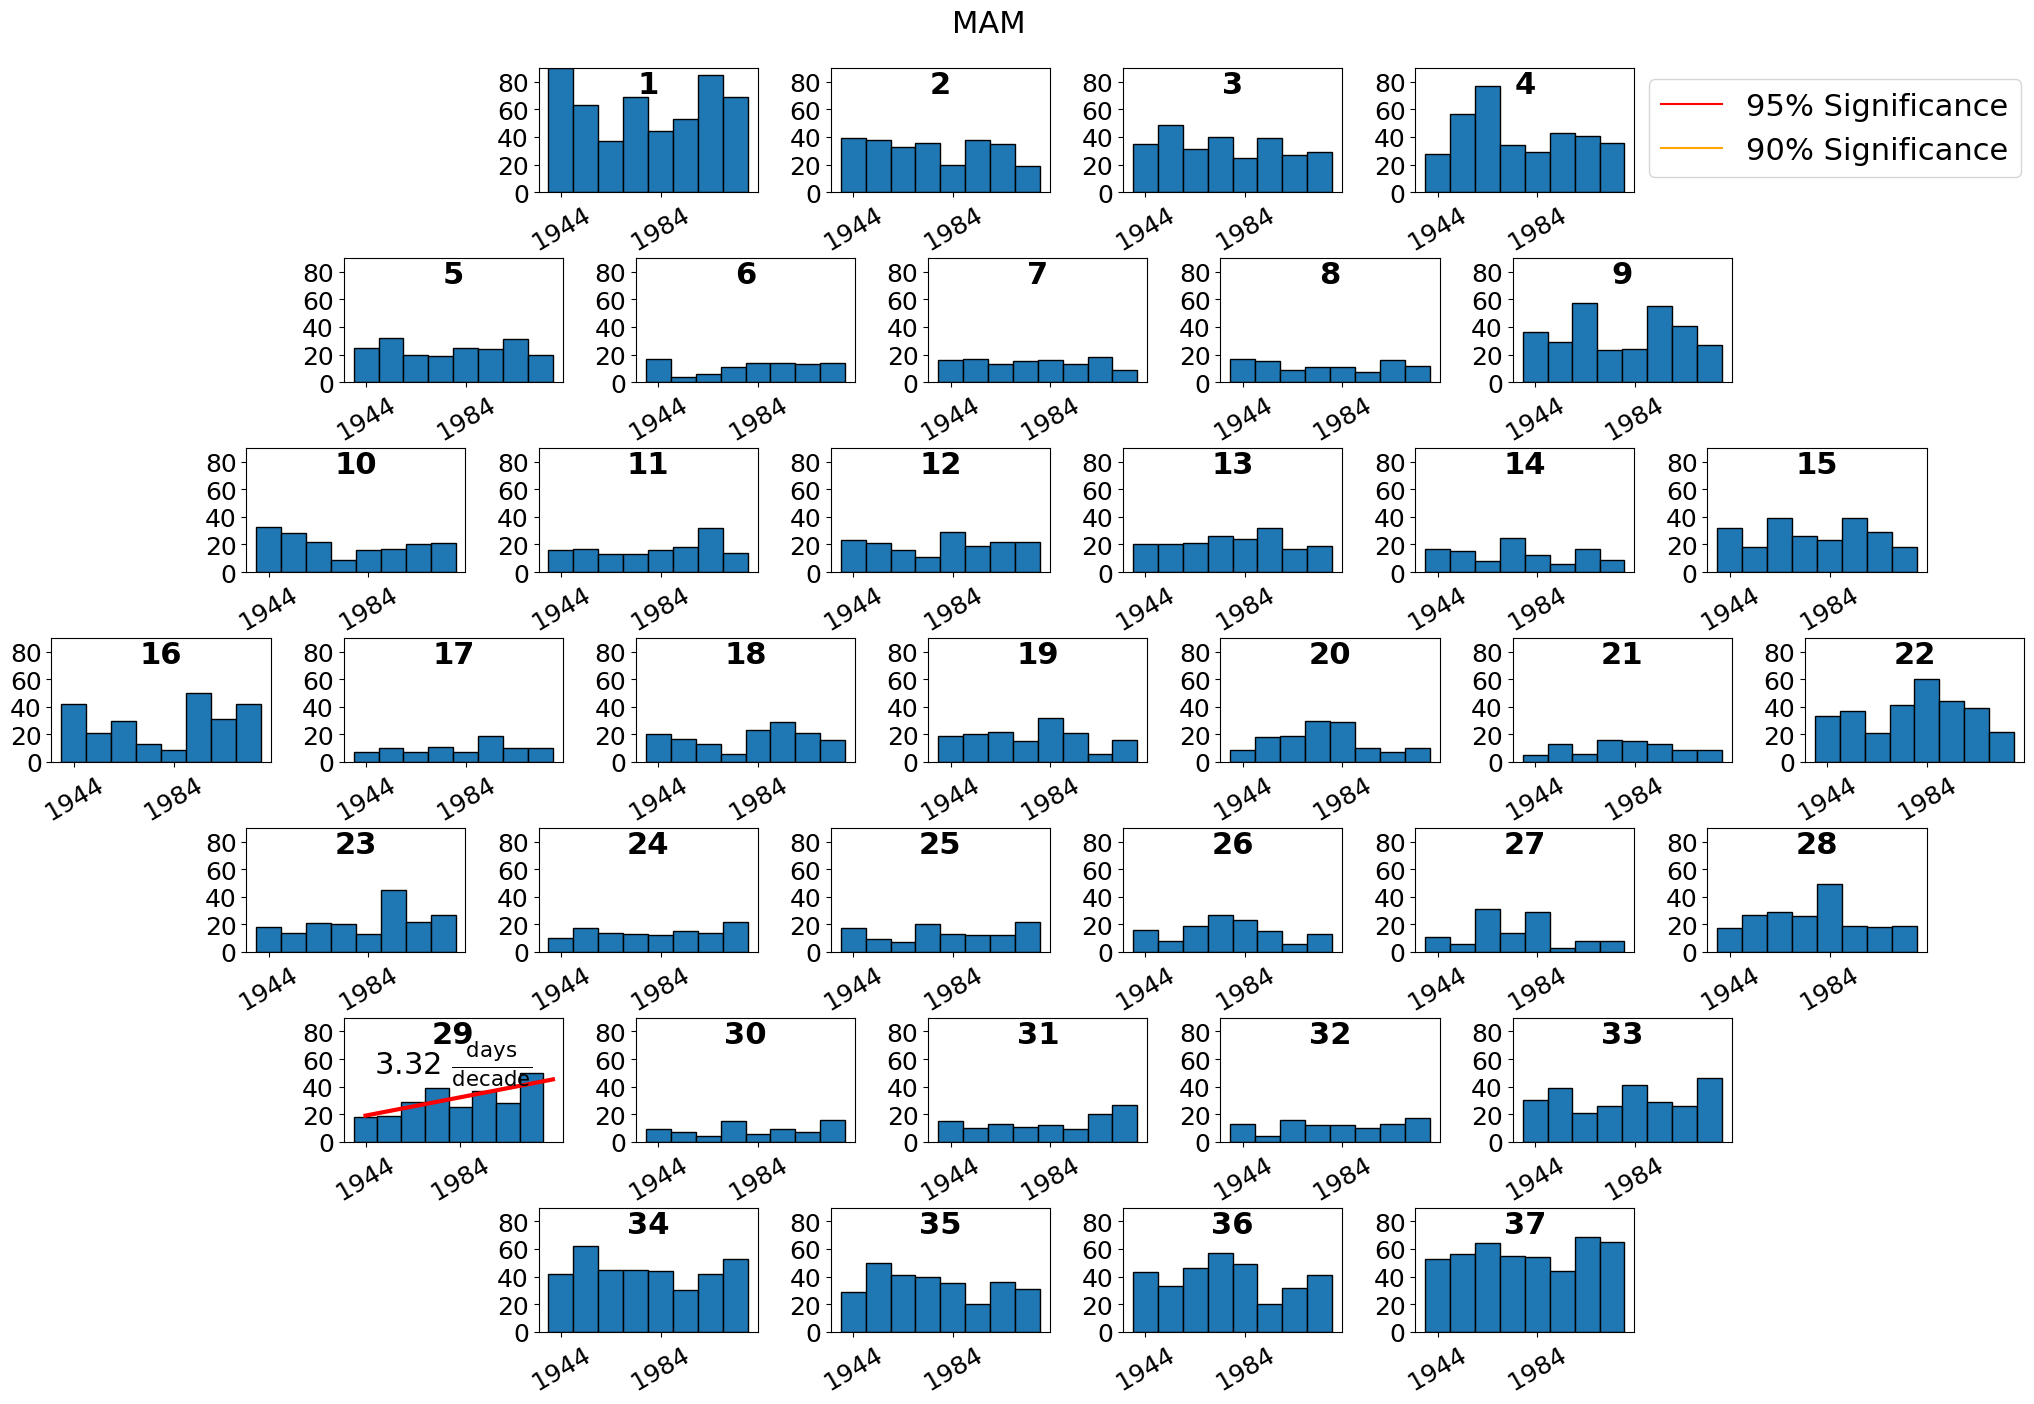

In [13]:
# ===========================
# MAM PLOT (permutation p-values)
# ===========================
plt.rcParams['text.usetex'] = False
fig, axs = hex_plot(som)
timeData = {}
maxBin = 80

fs = 22

for idx, node in enumerate(node_list):

    ax = axs[node[0], node[1]]
    indices = MAM_winmap.get(node, [])

    if len(indices) == 0:
        ax.set_xticks([])
        ax.set_yticks([0, 20, 40, 60, 80])
        ax.tick_params(axis='y', labelsize=fs - 4)
        ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})
        continue

    dates_labels = WR_labels_df.iloc[indices][['date', 'WR']]
    dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1944])

    if len(dates_labels_truncated) == 0:
        ax.set_xticks([])
        ax.set_yticks([0, 20, 40, 60, 80])
        ax.tick_params(axis='y', labelsize=fs - 4)
        ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})
        continue

    dates_labels_truncated['year_group'] = (
        (dates_labels_truncated['date'].dt.year - 4) // bin_size
    ) * bin_size + 4

    groups = dates_labels_truncated.groupby('year_group').size()

    if len(groups) == 0:
        ax.set_xticks([])
        ax.set_yticks([0, 20, 40, 60, 80])
        ax.tick_params(axis='y', labelsize=fs - 4)
        ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})
        continue

    if max(groups) > maxBin:
        maxBin = max(groups)

    ax.bar(groups.index, groups, width=bin_size, edgecolor='k')

    pval = MAM_pvals[idx]

    if len(groups) >= 2:
        z = np.polyfit(groups.index, groups, 1)
    else:
        z = None

    if (z is not None) and np.isfinite(pval) and (pval < 0.10):

        p = np.poly1d(z)
        x = np.arange(groups.index[0], groups.index[-1] + bin_size)
        y = p(x)

        if node == (1, 1):
            ax.text(
                .5, .55, f'{z[0]*10:.2f} ' + r'$\frac{\text{days}}{\text{decade}}$',
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        elif node == (5, 4):
            ax.text(
                .5, .4, f'{z[0]*10:.2f} ' + r'$\frac{\text{days}}{\text{decade}}$',
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        else:
            ax.text(
                .5, .5, f'{z[0]*10:.2f} ' + r'$\frac{\text{days}}{\text{decade}}$',
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )

        if pval < 0.05:
            color = 'r'
        else:
            color = 'orange'

        ax.plot(x, y, c=color, linewidth=3)

    ax.set_xticks(groups.index[::4])
    ax.set_yticks([0, 20, 40, 60, 80])
    ax.tick_params(axis='x', labelrotation=30, labelsize=fs - 4)
    ax.tick_params(axis='y', labelsize=fs - 4)
    ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})

for node in node_indices:
    axs[node[0], node[1]].set_ylim(0, maxBin)

plt.suptitle("MAM", y=1.0, fontsize=22)
fig.tight_layout()

plt.plot([1944], [0], color='r', label='95% Significance')
plt.plot([1944], [0], color='orange', label='90% Significance')
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 4.09), fontsize=fs)

plt.subplots_adjust(wspace=-0.2, hspace=2.25)

plt.savefig('node_count_trends_MAM.pdf', transparent=True, bbox_inches='tight')
plt.show()

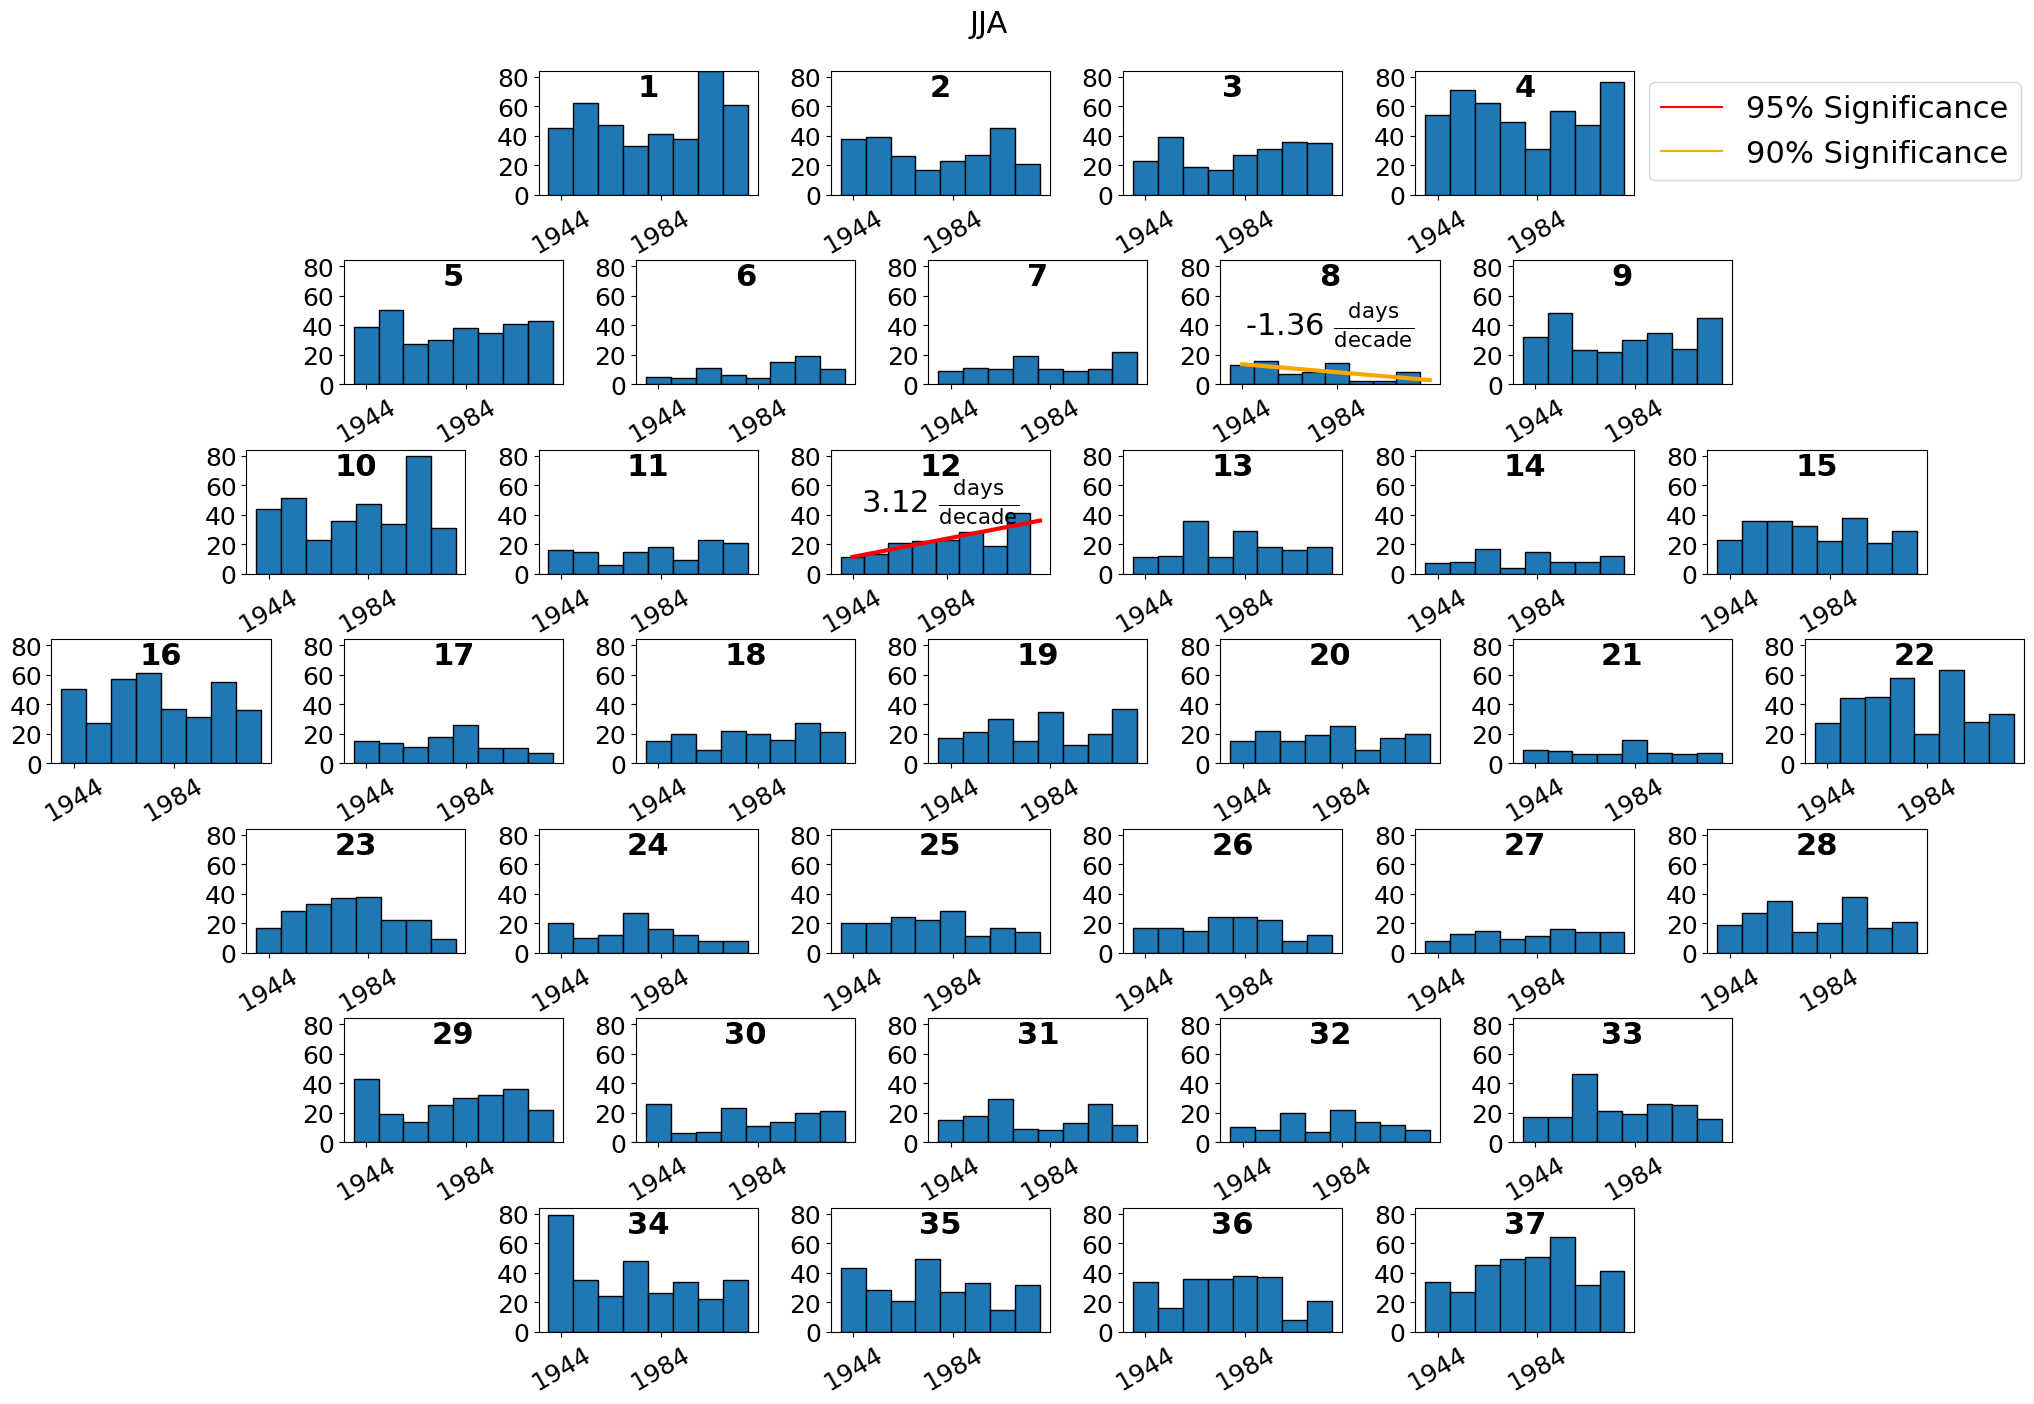

In [14]:
# ===========================
# JJA PLOT (permutation p-values)
# ===========================
plt.rcParams['text.usetex'] = False
fig, axs = hex_plot(som)
timeData = {}
maxBin = 80

fs = 22

for idx, node in enumerate(node_list):

    ax = axs[node[0], node[1]]
    indices = JJA_winmap.get(node, [])

    if len(indices) == 0:
        ax.set_xticks([])
        ax.set_yticks([0, 20, 40, 60, 80])
        ax.tick_params(axis='y', labelsize=fs - 4)
        ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})
        continue

    dates_labels = WR_labels_df.iloc[indices][['date', 'WR']]
    dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1944])

    if len(dates_labels_truncated) == 0:
        ax.set_xticks([])
        ax.set_yticks([0, 20, 40, 60, 80])
        ax.tick_params(axis='y', labelsize=fs - 4)
        ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})
        continue

    dates_labels_truncated['year_group'] = (
        (dates_labels_truncated['date'].dt.year - 4) // bin_size
    ) * bin_size + 4

    groups = dates_labels_truncated.groupby('year_group').size()

    if len(groups) == 0:
        ax.set_xticks([])
        ax.set_yticks([0, 20, 40, 60, 80])
        ax.tick_params(axis='y', labelsize=fs - 4)
        ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})
        continue

    if max(groups) > maxBin:
        maxBin = max(groups)

    ax.bar(groups.index, groups, width=bin_size, edgecolor='k')

    pval = JJA_pvals[idx]

    if len(groups) >= 2:
        z = np.polyfit(groups.index, groups, 1)
    else:
        z = None

    if (z is not None) and np.isfinite(pval) and (pval < 0.10):

        p = np.poly1d(z)
        x = np.arange(groups.index[0], groups.index[-1] + bin_size)
        y = p(x)

        if node == (1, 1):
            ax.text(
                .5, .55, f'{z[0]*10:.2f} ' + r'$\frac{\text{days}}{\text{decade}}$',
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        elif node == (5, 4):
            ax.text(
                .5, .4, f'{z[0]*10:.2f} ' + r'$\frac{\text{days}}{\text{decade}}$',
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        else:
            ax.text(
                .5, .5, f'{z[0]*10:.2f} ' + r'$\frac{\text{days}}{\text{decade}}$',
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )

        if pval < 0.05:
            color = 'r'
        else:
            color = 'orange'

        ax.plot(x, y, c=color, linewidth=3)

    ax.set_xticks(groups.index[::4])
    ax.set_yticks([0, 20, 40, 60, 80])
    ax.tick_params(axis='x', labelrotation=30, labelsize=fs - 4)
    ax.tick_params(axis='y', labelsize=fs - 4)
    ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})

for node in node_indices:
    axs[node[0], node[1]].set_ylim(0, maxBin)

plt.suptitle("JJA", y=1.0, fontsize=22)
fig.tight_layout()

plt.plot([1944], [0], color='r', label='95% Significance')
plt.plot([1944], [0], color='orange', label='90% Significance')
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 4.09), fontsize=fs)

plt.subplots_adjust(wspace=-0.2, hspace=2.25)

plt.savefig('node_count_trends_JJA.pdf', transparent=True, bbox_inches='tight')
plt.show()

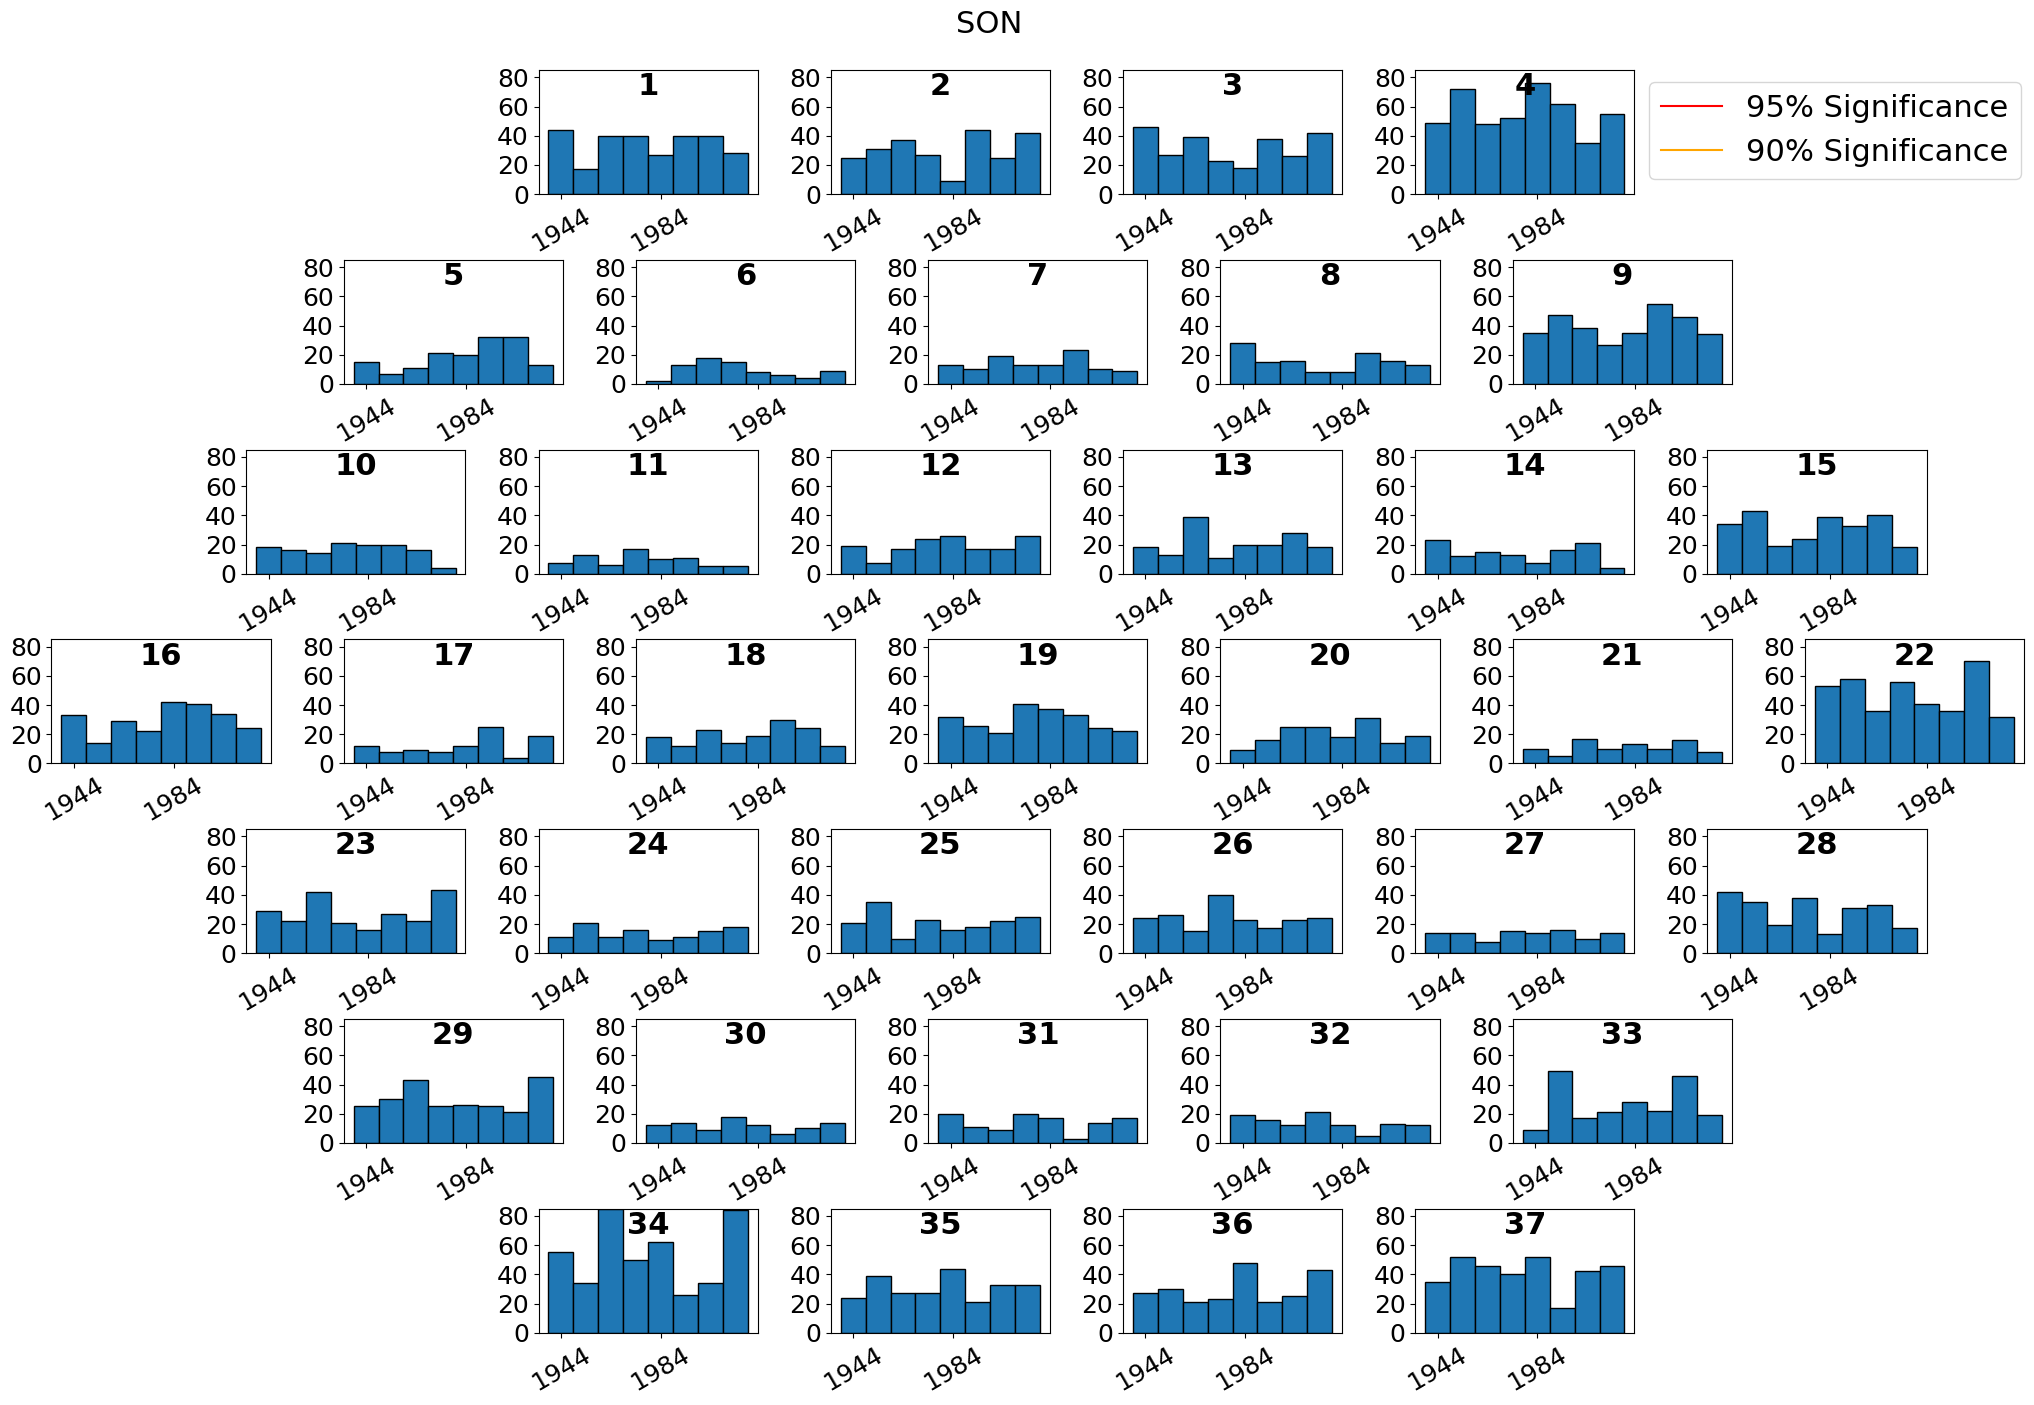

In [15]:
# ===========================
# SON PLOT (permutation p-values)
# ===========================
plt.rcParams['text.usetex'] = False
fig, axs = hex_plot(som)
timeData = {}
maxBin = 80

fs = 22

for idx, node in enumerate(node_list):

    ax = axs[node[0], node[1]]
    indices = SON_winmap.get(node, [])

    if len(indices) == 0:
        ax.set_xticks([])
        ax.set_yticks([0, 20, 40, 60, 80])
        ax.tick_params(axis='y', labelsize=fs - 4)
        ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})
        continue

    dates_labels = WR_labels_df.iloc[indices][['date', 'WR']]
    dates_labels_truncated = pd.DataFrame(dates_labels[dates_labels['date'].dt.year >= 1944])

    if len(dates_labels_truncated) == 0:
        ax.set_xticks([])
        ax.set_yticks([0, 20, 40, 60, 80])
        ax.tick_params(axis='y', labelsize=fs - 4)
        ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})
        continue

    dates_labels_truncated['year_group'] = (
        (dates_labels_truncated['date'].dt.year - 4) // bin_size
    ) * bin_size + 4

    groups = dates_labels_truncated.groupby('year_group').size()

    if len(groups) == 0:
        ax.set_xticks([])
        ax.set_yticks([0, 20, 40, 60, 80])
        ax.tick_params(axis='y', labelsize=fs - 4)
        ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})
        continue

    if max(groups) > maxBin:
        maxBin = max(groups)

    ax.bar(groups.index, groups, width=bin_size, edgecolor='k')

    pval = SON_pvals[idx]

    if len(groups) >= 2:
        z = np.polyfit(groups.index, groups, 1)
    else:
        z = None

    if (z is not None) and np.isfinite(pval) and (pval < 0.10):

        p = np.poly1d(z)
        x = np.arange(groups.index[0], groups.index[-1] + bin_size)
        y = p(x)

        if node == (1, 1):
            ax.text(
                .5, .55, f'{z[0]*10:.2f} ' + r'$\frac{\text{days}}{\text{decade}}$',
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        elif node == (5, 4):
            ax.text(
                .5, .4, f'{z[0]*10:.2f} ' + r'$\frac{\text{days}}{\text{decade}}$',
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )
        else:
            ax.text(
                .5, .5, f'{z[0]*10:.2f} ' + r'$\frac{\text{days}}{\text{decade}}$',
                transform=ax.transAxes, ha='center', fontdict={'fontsize': fs}
            )

        if pval < 0.05:
            color = 'r'
        else:
            color = 'orange'

        ax.plot(x, y, c=color, linewidth=3)

    ax.set_xticks(groups.index[::4])
    ax.set_yticks([0, 20, 40, 60, 80])
    ax.tick_params(axis='x', labelrotation=30, labelsize=fs - 4)
    ax.tick_params(axis='y', labelsize=fs - 4)
    ax.set_title(node_nums[node], y=.73, fontdict={'fontweight': 'bold', 'fontsize': fs})

for node in node_indices:
    axs[node[0], node[1]].set_ylim(0, maxBin)

plt.suptitle("SON", y=1.0, fontsize=22)
fig.tight_layout()

plt.plot([1944], [0], color='r', label='95% Significance')
plt.plot([1944], [0], color='orange', label='90% Significance')
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 4.09), fontsize=fs)

plt.subplots_adjust(wspace=-0.2, hspace=2.25)

plt.savefig('node_count_trends_SON.pdf', transparent=True, bbox_inches='tight')
plt.show()